<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>KNN Using sklearn on a Real Dataset</b>
</h1>

<div style="font-family:'Times New Roman';">

<b>Goal:</b>

<ol>
<li>Train a KNN model on a real dataset.</li>
<li>Understand why feature scaling is important in KNN.</li>
<li>Evaluate the model using different classification metrics.</li>
<li>Observe how different values of K affect performance.</li>
</ol>

In this notebook, I'll use the Breast Cancer dataset to see how KNN makes predictions based on the nearest neighbors and how choosing the right value of K can impact the results.

</div>

In [1]:
# import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
# load dataset

data = load_breast_cancer()

X = data.data
y = data.target

In [3]:
# dataset information

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

print("\nClasses :", data.target_names)

Features Shape : (569, 30)
Target Shape : (569,)

Classes : ['malignant' 'benign']


In [4]:
# convert to dataframe

df = pd.DataFrame(X, columns=data.feature_names)

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
# class distribution

pd.Series(y).value_counts()

1    357
0    212
Name: count, dtype: int64

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Observation</b>
</h2>

<div style="font-family:'Times New Roman';">

This is a <b>binary classification</b> problem.

<ul>
<li><b>0:</b> Malignant</li>
<li><b>1:</b> Benign</li>
</ul>

The goal is to predict whether a tumor is malignant or benign based on the given medical measurements.

</div>

In [ ]:
# train test split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42
)

In [7]:
# feature scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Why Scaling?</b>
</h2>

<div style="font-family:'Times New Roman';">

KNN relies completely on <b>distance calculations</b> to find the nearest neighbors.

If one feature has much larger values than the others, it can dominate the distance calculation and have a bigger influence on the prediction.

Scaling helps bring all features to a similar range so that each feature contributes fairly while calculating distances.

</div>

In [8]:
# train knn model

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [9]:
# predictions

y_pred = knn.predict(X_test)

In [10]:
# accuracy

acc = accuracy_score(y_test, y_pred)

print("Accuracy :", round(acc,4))

Accuracy : 0.9474


In [11]:
# confusion matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[40  3]
 [ 3 68]]


In [12]:
# detailed evaluation

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Evaluation Metrics</b>
</h2>

<div style="font-family:'Times New Roman';">

These metrics help us understand how well the model is performing.

<ul>
<li><b>Accuracy:</b> Overall percentage of correct predictions.</li>

<li><b>Precision:</b> Out of all predicted positive samples, how many were actually positive.</li>

<li><b>Recall:</b> Out of all actual positive samples, how many were correctly identified.</li>

<li><b>F1 Score:</b> A balance between Precision and Recall.</li>
</ul>

Looking at multiple metrics gives a better understanding of model performance than relying only on accuracy.

</div>

**K Value Experiment**

In [13]:
# try different k values

scores = []

for k in range(1,21):

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    scores.append(acc)

In [14]:
# accuracy for each k

for k, score in enumerate(scores, start=1):
    print(f"K={k} --> Accuracy={score:.4f}")

K=1 --> Accuracy=0.9386
K=2 --> Accuracy=0.9386
K=3 --> Accuracy=0.9474
K=4 --> Accuracy=0.9561
K=5 --> Accuracy=0.9474
K=6 --> Accuracy=0.9561
K=7 --> Accuracy=0.9474
K=8 --> Accuracy=0.9561
K=9 --> Accuracy=0.9649
K=10 --> Accuracy=0.9561
K=11 --> Accuracy=0.9561
K=12 --> Accuracy=0.9561
K=13 --> Accuracy=0.9561
K=14 --> Accuracy=0.9561
K=15 --> Accuracy=0.9561
K=16 --> Accuracy=0.9561
K=17 --> Accuracy=0.9474
K=18 --> Accuracy=0.9561
K=19 --> Accuracy=0.9474
K=20 --> Accuracy=0.9561


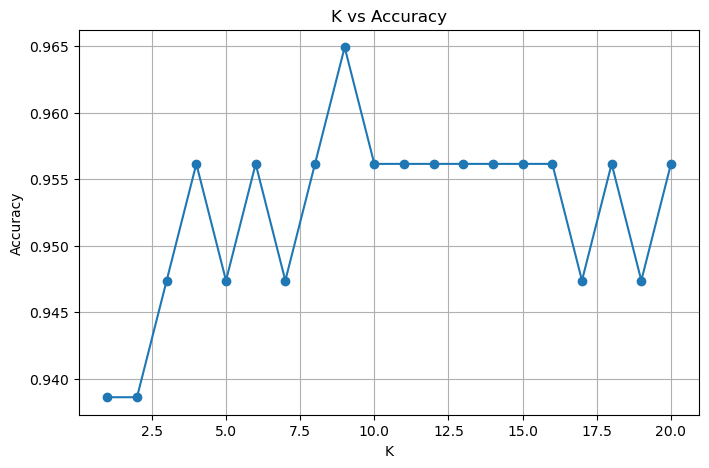

In [15]:
# visualize k vs accuracy

plt.figure(figsize=(8,5))

plt.plot(range(1,21), scores, marker='o')

plt.xlabel("K")
plt.ylabel("Accuracy")

plt.title("K vs Accuracy")

plt.grid()

plt.show()

In [16]:
# best k

best_k = np.argmax(scores) + 1

print("Best K :", best_k)
print("Best Accuracy :", max(scores))

Best K : 9
Best Accuracy : 0.9649122807017544


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Conclusion</b>
</h2>

<div style="font-family:'Times New Roman';">

<ul>
<li>KNN is a <b>supervised, distance-based</b> learning algorithm.</li>

<li>Unlike many ML algorithms, KNN does not actually learn parameters during training. The training data is simply stored.</li>

<li>Predictions are made by finding the <b>K nearest neighbors</b> and using majority voting.</li>

<li>Feature scaling is important because KNN relies on distance calculations.</li>

<li>A small value of <b>K</b> can lead to overfitting, while a large value can lead to underfitting.</li>

<li>KNN performed well on the Breast Cancer dataset and achieved high classification accuracy.</li>
</ul>

<b>KNN Workflow:</b>

<pre>
Store Training Data
        ↓
Calculate Distances
        ↓
Find K Nearest Neighbors
        ↓
Majority Voting
        ↓
Prediction
</pre>

</div>